In [1]:
import zipfile
import os

zip_path = "/content/online_retail.csv.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/online_retail")

os.listdir("/content/online_retail")

['online_retail.csv']

In [2]:
import pandas as pd

df = pd.read_csv("/content/online_retail/online_retail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove rows with missing Description
df = df.dropna(subset=['Description'])

print("Shape after removing missing values:")
print(df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Shape after removing missing values:
(406829, 8)

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [5]:
# Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("Shape after removing cancelled transactions:")
print(df.shape)

print("\nNumber of cancelled transactions remaining:")
print(df['InvoiceNo'].astype(str).str.startswith('C').sum())

Shape after removing cancelled transactions:
(397924, 8)

Number of cancelled transactions remaining:
0


In [6]:
# Calculate total purchase value for each transaction
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [7]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].dtype)
print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

datetime64[ns]
2010-12-01 08:26:00
2011-12-09 12:50:00


In [8]:
# Set the analysis date as one day after the last transaction
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics for each customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [9]:
print("RFM Descriptive Statistics:")
print(rfm.describe())

RFM Descriptive Statistics:
           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     92.518322     4.271952    2053.793018
std     100.009747     7.705493    8988.248381
min       1.000000     1.000000       0.000000
25%      18.000000     1.000000     307.245000
50%      51.000000     2.000000     674.450000
75%     142.000000     5.000000    1661.640000
max     374.000000   210.000000  280206.020000


In [10]:
from sklearn.preprocessing import StandardScaler

# Select RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("Scaled RFM data:")
print(rfm_scaled[:5])

Scaled RFM data:
[[ 2.33485829 -0.42467487  8.35963391]
 [-0.90519931  0.35408019  0.25104636]
 [-0.17518634 -0.03529734 -0.02854645]
 [-0.73519629 -0.42467487 -0.03296273]
 [ 2.17485544 -0.42467487 -0.19131549]]


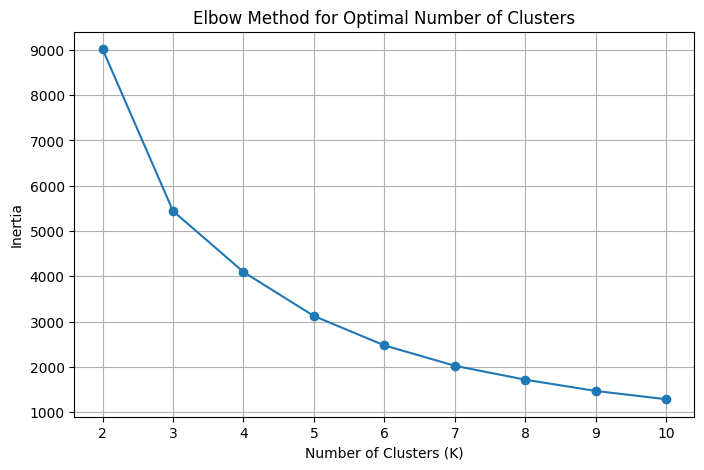

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

### Observation

The Elbow Method shows a significant decrease in inertia as the number of clusters increases. The curve begins to flatten after **K = 4**, indicating that four clusters provide a reasonable balance between reducing within-cluster variation and keeping the number of customer segments manageable. Therefore, **K = 4** is selected for the K-Means clustering analysis.

In [12]:
# Apply K-Means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Cluster assignment:")
print(rfm.head())

Cluster assignment:
            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        0
12347.0           2          7   4310.00        3
12348.0          75          4   1797.24        3
12349.0          19          1   1757.55        3
12350.0         310          1    334.40        1


In [13]:
print("\nNumber of customers in each cluster:")
print(rfm['Cluster'].value_counts().sort_index())


Number of customers in each cluster:
Cluster
0     211
1    1062
2      13
3    3053
Name: count, dtype: int64


### Observation

The K-Means algorithm divided the 4,339 customers into four clusters. Cluster 3 contains the largest number of customers with 3,053 customers, followed by Cluster 1 with 1,062 customers. Cluster 0 contains 211 customers, while Cluster 2 is the smallest group with only 13 customers. This shows that the customer base is unevenly distributed across the four segments.

In [14]:
# Calculate average RFM values for each cluster
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

print("Customer Segment Profile:")
print(cluster_profile)

Customer Segment Profile:
            Recency  Frequency       Monetary
Cluster                                      
0         15.672986  22.047393   12453.225924
1        248.564030   1.551789     478.107581
2          7.384615  82.692308  127338.313846
3         43.910580   3.655748    1349.698298


### Cluster Profile Observation

The customer segmentation reveals four distinct customer groups:

- **Cluster 0 – Loyal High-Value Customers:** These customers purchased recently, have a high purchase frequency, and have spent a substantial amount. They represent valuable and loyal customers.

- **Cluster 1 – At-Risk / Inactive Customers:** These customers have the highest recency value, meaning they have not purchased for a long time. Their purchase frequency and monetary value are also relatively low.

- **Cluster 2 – VIP Customers:** This is a very small but highly valuable segment. These customers have very recent purchases, extremely high purchase frequency, and the highest monetary value.

- **Cluster 3 – Regular Customers:** These customers show moderate recency, frequency, and spending. They form the largest customer segment and represent the regular customer base.

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x600 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

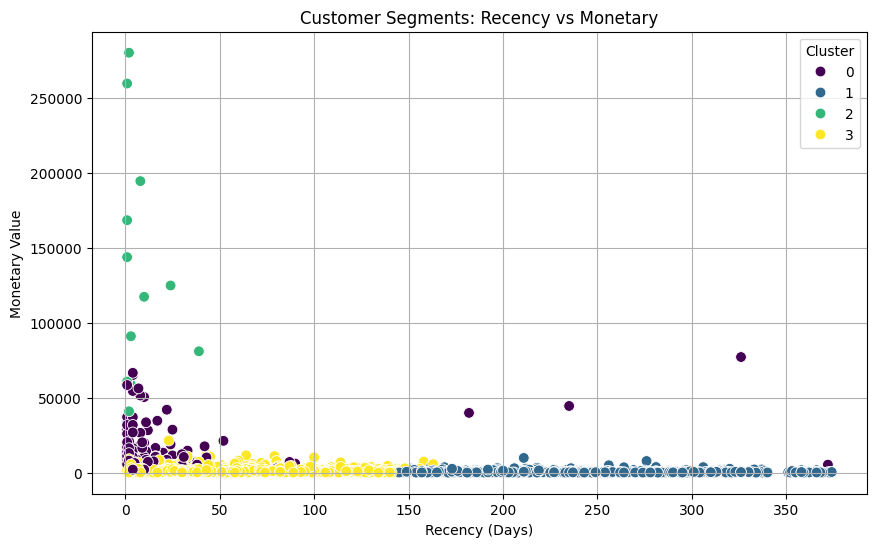

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### Observation

The scatter plot shows clear differences between the four customer segments. Cluster 2 represents a very small group of customers with very high monetary values and very recent purchases, identifying them as VIP customers. Cluster 0 also contains relatively recent and high-spending customers. Cluster 1 is concentrated at higher recency values with low monetary values, indicating inactive or at-risk customers. Cluster 3 forms the largest group and is mainly concentrated around moderate recency and lower spending levels, representing regular customers.

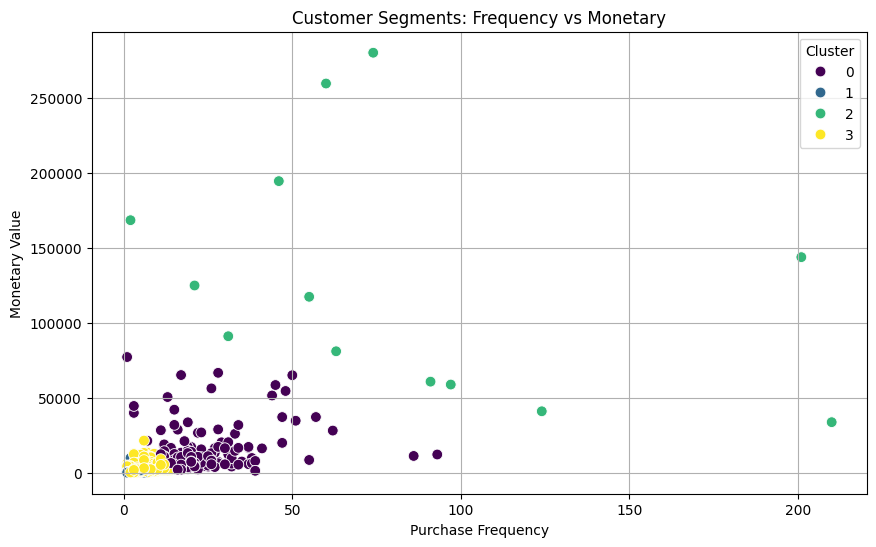

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### Observation

The scatter plot shows a clear relationship between purchase frequency and monetary value across the customer segments. Cluster 2 contains customers with exceptionally high purchase frequencies and monetary values, identifying them as VIP customers. Cluster 0 consists of customers with relatively higher frequency and spending compared with the regular customer group. Cluster 1 has low purchase frequency and low monetary value, representing inactive or at-risk customers. Cluster 3 contains the largest number of customers with generally lower to moderate purchase frequency and spending, representing regular customers.

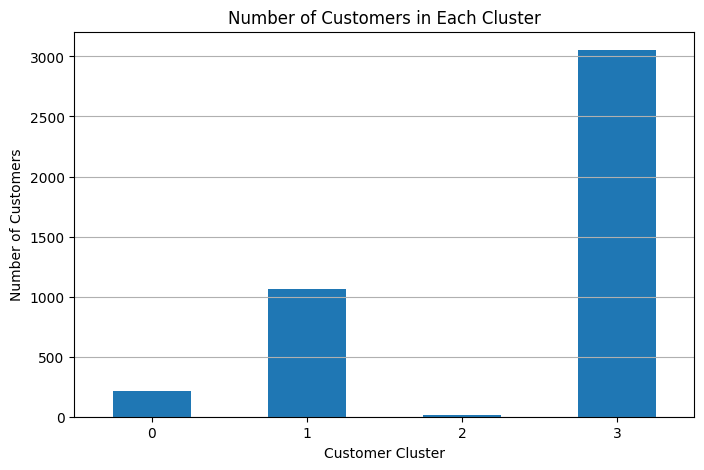

In [20]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar')

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Observation

The customer distribution is uneven across the four clusters. **Cluster 3** is the largest segment with **3,053 customers**, followed by **Cluster 1** with **1,062 customers**. **Cluster 0** contains **211 customers**, while **Cluster 2** is the smallest segment with only **13 customers**. Although Cluster 2 is small, its customers have exceptionally high purchase frequency and monetary value, making them an important high-value segment.

## Marketing Recommendations

### Cluster 0 – Loyal High-Value Customers
These customers purchase frequently and spend a significant amount.

**Recommended action:**  
Provide loyalty rewards, personalized offers, early access to new products, and premium customer benefits to encourage continued purchases.

### Cluster 1 – At-Risk / Inactive Customers
These customers have not purchased recently and have relatively low purchase frequency and spending.

**Recommended action:**  
Use re-engagement campaigns, personalized discounts, and reminders to encourage them to return.

### Cluster 2 – VIP Customers
This is a very small but extremely valuable group with very high purchase frequency and spending.

**Recommended action:**  
Provide VIP membership benefits, exclusive offers, personalized service, and early access to premium products to retain these customers.

### Cluster 3 – Regular Customers
This is the largest customer segment with moderate purchase activity and spending.

**Recommended action:**  
Use targeted promotions, product recommendations, and loyalty programs to increase their purchase frequency and gradually move them toward the high-value segments.

## Conclusion

Customer segmentation was performed using RFM (Recency, Frequency, and Monetary) analysis and K-Means clustering. The Elbow Method was used to select four customer clusters.

The analysis identified four distinct customer segments: Loyal High-Value Customers, At-Risk / Inactive Customers, VIP Customers, and Regular Customers. The segments differ significantly in their purchase recency, frequency, and spending behaviour.

The segmentation can help the business understand customer behaviour and develop targeted marketing strategies. High-value customers can be retained through loyalty and VIP programs, inactive customers can be re-engaged through personalized offers, and regular customers can be encouraged to increase their purchase frequency.

Overall, RFM-based K-Means clustering provides a useful approach for making customer-focused marketing decisions.